# ConcentrationsDataset Demo

This notebook demonstrates how to use the `ConcentrationsDataset` class for loading paired concentration maps from spectral unmixing results. The dataset handles both reduced wavelength and ground truth concentration maps with convenient lookup methods.

## Import Required Libraries

Import all necessary modules for working with the ConcentrationsDataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
from typing import Dict, List, Union
import torch
from torch.utils.data import Dataset

# Add project root to path
sys.path.append('..')

# Import project modules
from src.wavelength_selection.enums import SampleType
from src.dataset.concentrations_dataset import ConcentrationsDataset
from src.dataset.dataset_utils import split_dataset_with_ids
from src.wavelength_selection.metrics import nrmse, rmse
from src.molecules import MoleculeIndex
from src.visualize_data import plot_inferred_concentrations

Loaded 61 patient IDs from metadata CSV


## Initialize ConcentrationsDataset

Create an instance of the ConcentrationsDataset with paths to the reduced wavelength and ground truth concentration maps.

In [2]:
# Define paths to your concentration map directories
# These should contain subdirectories with spectral unmixing results
reduced_wl_dir = "../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750_reduced"
gt_dir = "../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750"

# Initialize the dataset
try:
    dataset = ConcentrationsDataset(
        reduced_wl_dir=reduced_wl_dir,
        gt_dir=gt_dir,
        sample_type=SampleType.HELICOID,
        center_crop_size=(224, 224),  # Example crop size, adjust as needed
    )
    print(f"Successfully created dataset with {len(dataset)} samples")
    
    # Get dataset summary
    summary = dataset.get_summary()
    print("\nDataset Summary:")
    for key, value in summary.items():
        if key == "patient_fov_counts":
            print(f"  {key}:")
            for patient, count in value.items():
                print(f"    {patient}: {count} FOVs")
        else:
            print(f"  {key}: {value}")
            
except Exception as e:
    print(f"Error creating dataset: {e}")
    print("Please ensure the directory paths exist and contain valid data")
    
    # Create dummy directories for demonstration if paths don't exist
    print("\nNote: The actual paths depend on your spectral unmixing results.")
    print("Update the paths above to point to your actual data directories.")

Found 70 common samples between directories
Successfully created dataset with 70 samples

Dataset Summary:
  total_samples: 70
  num_patients: 40
  patient_ids: ['004', '005', '007', '008', '010', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '025', '026', '027', '028', '029', '030', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '050', '051', '053', '054', '055', '056', '057', '058']
  patient_fov_counts:
    004: 1 FOVs
    005: 1 FOVs
    007: 1 FOVs
    008: 2 FOVs
    010: 1 FOVs
    012: 2 FOVs
    013: 1 FOVs
    014: 1 FOVs
    015: 1 FOVs
    016: 5 FOVs
    017: 1 FOVs
    018: 2 FOVs
    019: 1 FOVs
    020: 1 FOVs
    021: 3 FOVs
    022: 3 FOVs
    025: 1 FOVs
    026: 1 FOVs
    027: 1 FOVs
    028: 3 FOVs
    029: 2 FOVs
    030: 1 FOVs
    034: 3 FOVs
    035: 2 FOVs
    036: 2 FOVs
    037: 4 FOVs
    038: 1 FOVs
    039: 2 FOVs
    040: 2 FOVs
    041: 2 FOVs
    042: 3 FOVs
    043: 3 FOVs
    050: 1 FOVs
    051:

In [3]:
min_width = 1000000
min_height = 1000000

for sample in dataset:
    # Get the image and concentration map
    delta_c = sample['reduced_wl']['coef_list']
    
    # Update min dimensions
    min_width = min(min_width, delta_c.shape[1])
    min_height = min(min_height, delta_c.shape[0])
    
    # Print sample details
    print(f"Sample ID: {sample['id']}, delta_c shape: {delta_c.shape}")
print(f"Minimum dimensions across all samples: {min_height}x{min_width}")

Sample ID: 004-02, delta_c shape: (224, 224, 10)
Sample ID: 005-01, delta_c shape: (224, 224, 10)
Sample ID: 007-01, delta_c shape: (224, 224, 10)
Sample ID: 008-01, delta_c shape: (224, 224, 10)
Sample ID: 008-02, delta_c shape: (224, 224, 10)
Sample ID: 010-03, delta_c shape: (224, 224, 10)
Sample ID: 012-01, delta_c shape: (224, 224, 10)
Sample ID: 012-02, delta_c shape: (224, 224, 10)
Sample ID: 013-01, delta_c shape: (224, 224, 10)
Sample ID: 014-01, delta_c shape: (224, 224, 10)
Sample ID: 015-01, delta_c shape: (224, 224, 10)
Sample ID: 016-01, delta_c shape: (224, 224, 10)
Sample ID: 016-02, delta_c shape: (224, 224, 10)
Sample ID: 016-03, delta_c shape: (224, 224, 10)
Sample ID: 016-04, delta_c shape: (224, 224, 10)
Sample ID: 016-05, delta_c shape: (224, 224, 10)
Sample ID: 017-01, delta_c shape: (224, 224, 10)
Sample ID: 018-01, delta_c shape: (224, 224, 10)
Sample ID: 018-02, delta_c shape: (224, 224, 10)
Sample ID: 019-01, delta_c shape: (224, 224, 10)
Sample ID: 020-01, d

## Basic Dataset Operations

Demonstrate basic dataset operations like accessing samples by index and examining data structure.

In [ ]:
# Check if dataset was successfully created
if 'dataset' in locals() and len(dataset) > 0:
    # Access a sample by index
    sample_idx = 0
    sample = dataset[sample_idx]
    
    print(f"Sample {sample_idx}:")
    print(f"  ID: {sample['id']}")
    print(f"  Patient ID: {sample['patient_id']}")
    print(f"  FOV: {sample['fov']}")
    
    # Examine the data structure
    print("\nReduced wavelength data keys:", list(sample['reduced_wl'].keys()))
    print("Ground truth data keys:", list(sample['gt'].keys()))
    
    # Check shapes of concentration maps
    reduced_coef = sample['reduced_wl']['coef_list']
    gt_coef = sample['gt']['coef_list']
    
    print(f"\nData shapes:")
    print(f"  Reduced WL concentrations: {reduced_coef.shape}")
    print(f"  Ground truth concentrations: {gt_coef.shape}")
    
    if 'scatter_params' in sample['reduced_wl']:
        print(f"  Reduced WL scatter params: {sample['reduced_wl']['scatter_params'].shape}")
    if 'scatter_params' in sample['gt']:
        print(f"  Ground truth scatter params: {sample['gt']['scatter_params'].shape}")
        
else:
    print("Dataset not available. Please check the directory paths and try again.")

Sample 0:
  ID: 004-02
  Patient ID: 004
  FOV: 02

Reduced wavelength data keys: ['coef_list', 'scatter_params']
Ground truth data keys: ['coef_list', 'scatter_params']

Data shapes:
  Reduced WL concentrations: (224, 224, 10)
  Ground truth concentrations: (224, 224, 10)
  Reduced WL scatter params: (224, 224, 2)
  Ground truth scatter params: (224, 224, 2)


## Sample Lookup by ID

Demonstrate how to retrieve samples using the convenient lookup methods.

In [5]:
# Get list of available patient IDs
patient_ids = dataset.get_patient_ids()
print("Available patient IDs:", patient_ids, "..." if len(patient_ids) > 5 else "")

# 1. Get sample by specific ID
if len(dataset) > 0:
    sample_id = dataset.samples[0]["id"]  # Use first available sample ID
    print(f"\n1. Getting sample by ID '{sample_id}':")
    sample_by_id = dataset.get_sample_by_id(sample_id)
    if sample_by_id:
        print(f"   Found sample: Patient {sample_by_id['patient_id']}, FOV {sample_by_id['fov']}")
    
# 2. Get all samples for a specific patient
if patient_ids:
    patient_id = patient_ids[0]
    print(f"\n2. Getting all samples for patient '{patient_id}':")
    patient_samples = dataset.get_samples_by_patient_id(patient_id)
    print(f"   Found {len(patient_samples)} samples")
    for sample in patient_samples:
        print(f"   - ID: {sample['id']}, FOV: {sample['fov']}")

# 3. Get sample by patient ID and FOV
if patient_ids:
    patient_id = patient_ids[0]
    fovs = dataset.get_fovs_for_patient(patient_id)
    if fovs:
        fov = fovs[0]
        print(f"\n3. Getting sample for patient '{patient_id}', FOV '{fov}':")
        sample_by_patient_fov = dataset.get_sample_by_patient_and_fov(patient_id, fov)
        if sample_by_patient_fov:
            print(f"   Found sample: ID {sample_by_patient_fov['id']}")

Available patient IDs: ['004', '005', '007', '008', '010', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '025', '026', '027', '028', '029', '030', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '050', '051', '053', '054', '055', '056', '057', '058'] ...

1. Getting sample by ID '004-02':
   Found sample: Patient 004, FOV 02

2. Getting all samples for patient '004':
   Found 1 samples
   - ID: 004-02, FOV: 02

3. Getting sample for patient '004', FOV '02':
   Found sample: ID 004-02


## Concentration Map Comparison

Compare reduced wavelength vs ground truth concentration maps to evaluate the impact of wavelength reduction.

In [6]:

# Get a sample for comparison
sample = dataset[0]

reduced_conc = sample['reduced_wl']['coef_list']
gt_conc = sample['gt']['coef_list']

print(f"Comparing concentrations for sample {sample['id']}:")

# Calculate error metrics
try:
    nrmse_error = nrmse(gt_conc, reduced_conc)
    rmse_error = rmse(gt_conc, reduced_conc)
    
    print(f"NRMSE between GT and reduced WL: {nrmse_error:.4f}")
    print(f"RMSE between GT and reduced WL: {rmse_error:.4f}")
    
    # Calculate mean concentrations for each molecule
    mean_reduced = np.mean(reduced_conc, axis=(0, 1))
    mean_gt = np.mean(gt_conc, axis=(0, 1))
    
    print(f"\nMean concentrations comparison:")
    print(f"{'Molecule':<15} {'Reduced WL':<12} {'Ground Truth':<12} {'Difference':<12}")
    print("-" * 55)
    
    molecule_names = [
        "HbO2", "Hb", "oxCCO", "redCCO", "Cyt-c oxy", "Cyt-c red", 
        "Cyt-b oxy", "Cyt-b red", "Water", "Fat"
    ]
    
    for i, name in enumerate(molecule_names[:min(len(molecule_names), reduced_conc.shape[2])]):
        diff = mean_reduced[i] - mean_gt[i]
        print(f"{name:<15} {mean_reduced[i]:<12.4f} {mean_gt[i]:<12.4f} {diff:<12.4f}")
        
except Exception as e:
    print(f"Error calculating metrics: {e}")
    print("This might be due to shape mismatch or missing data.")
    

Comparing concentrations for sample 004-02:
NRMSE between GT and reduced WL: 0.2131
RMSE between GT and reduced WL: 1.9975

Mean concentrations comparison:
Molecule        Reduced WL   Ground Truth Difference  
-------------------------------------------------------
HbO2            0.0009       0.0010       -0.0001     
Hb              0.0060       0.0040       0.0020      
oxCCO           -0.0092      -0.0080      -0.0012     
redCCO          0.0014       0.0018       -0.0004     
Cyt-c oxy       0.0396       0.0078       0.0318      
Cyt-c red       -0.0010      -0.0006      -0.0003     
Cyt-b oxy       -0.0963      -0.0176      -0.0787     
Cyt-b red       0.0001       -0.0013      0.0013      
Water           4.1126       3.8921       0.2205      
Fat             -41.7949     -40.8449     -0.9500     


## Visualization

Visualize the concentration maps to see spatial differences between reduced wavelength and ground truth results.

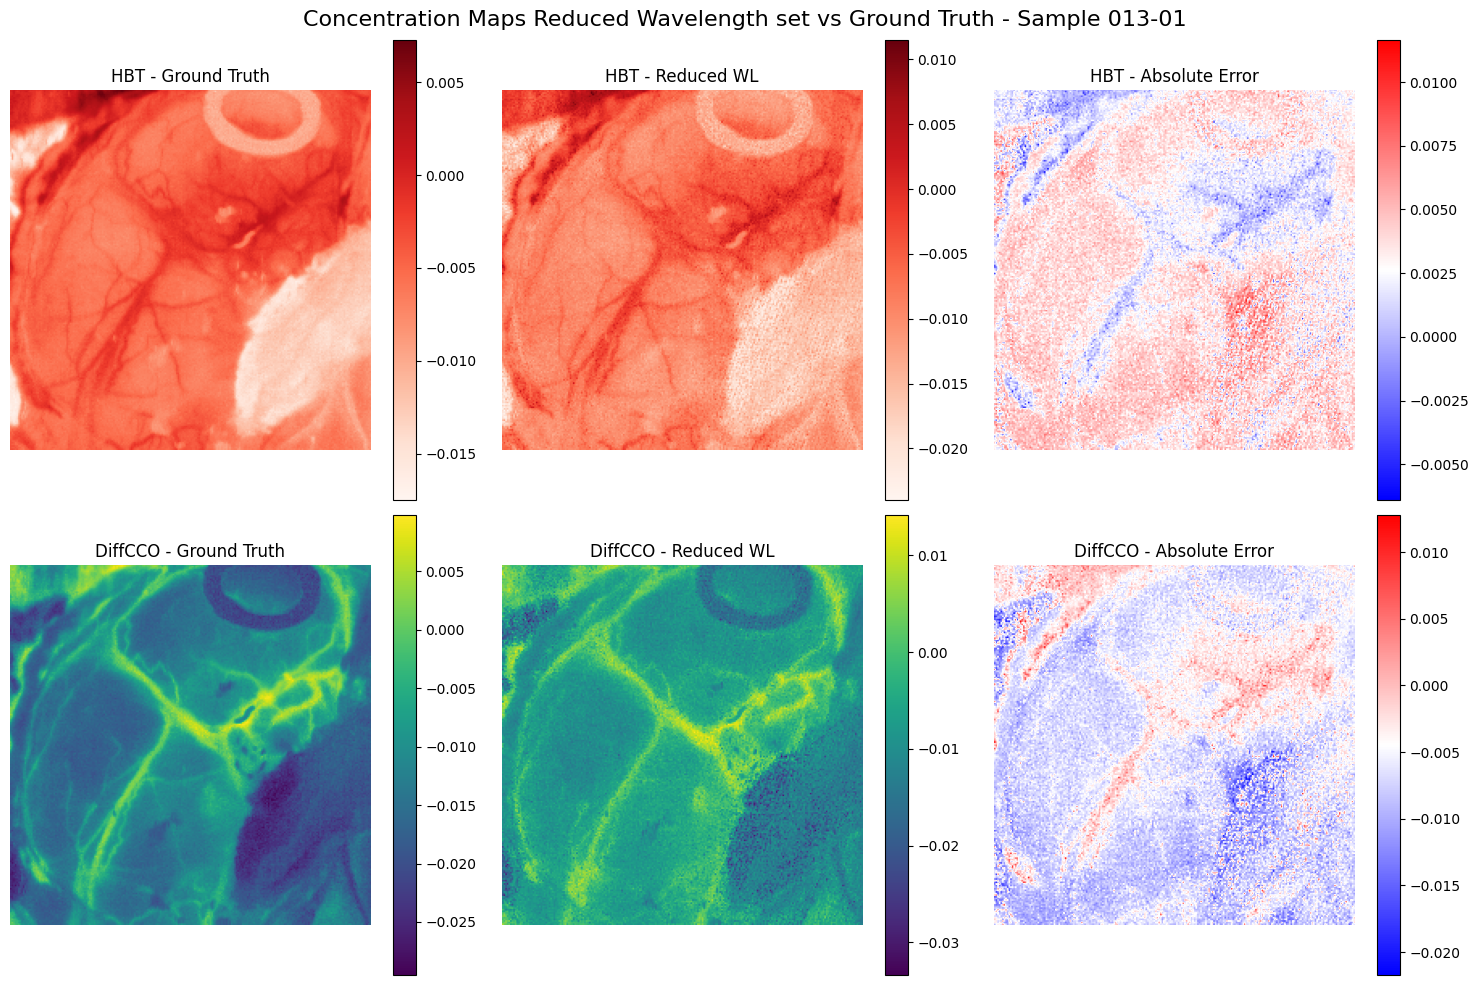

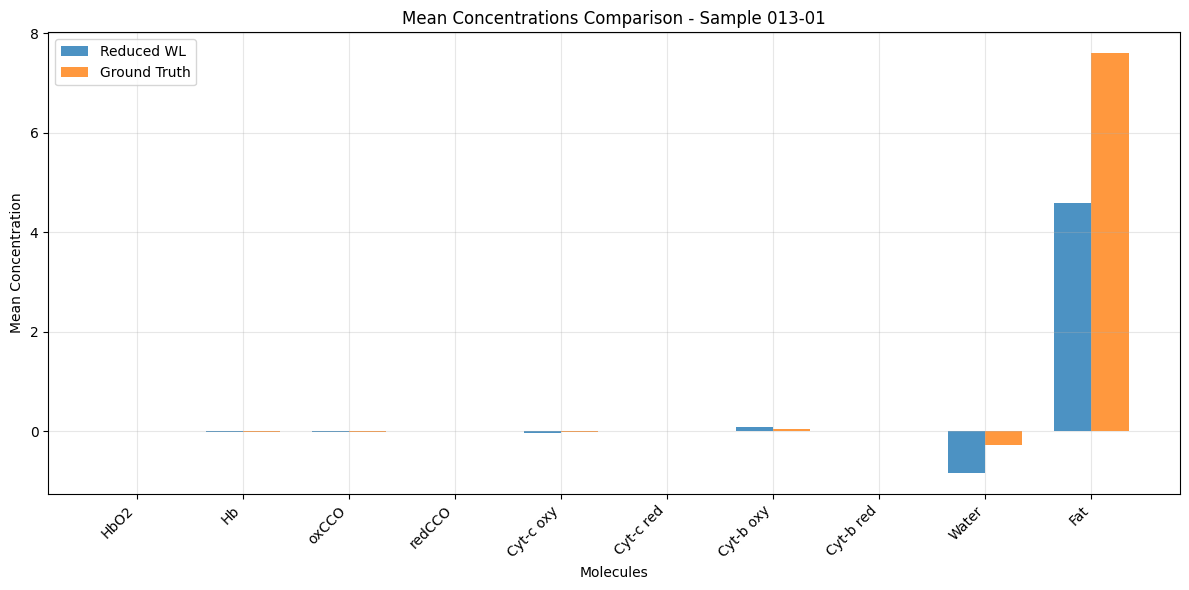

In [7]:
# Get a sample for visualization
from src.molecules import MoleculeIndex
sample = dataset.get_sample_by_id('013-01')
coarseness = 1

reduced_conc = sample['reduced_wl']['coef_list']
gt_conc = sample['gt']['coef_list']

# Prepare maps
def sub(m):
    return m[::coarseness, ::coarseness]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Concentration Maps Reduced Wavelength set vs Ground Truth - Sample {sample["id"]}', fontsize=16)


gt_HBT = sub(gt_conc[:, :, MoleculeIndex.HB] + gt_conc[:, :, MoleculeIndex.HBO2])
# Ground truth HBT
im2 = axes[0, 0].imshow(gt_HBT, cmap='Reds')
axes[0, 0].set_title(f'HBT - Ground Truth')
axes[0, 0].axis('off')
plt.colorbar(im2, ax=axes[0, 0])

reduced_HBT = sub(reduced_conc[:, :, MoleculeIndex.HB] + reduced_conc[:, :, MoleculeIndex.HBO2])
# Reduced wavelength HBT
im1 = axes[0, 1].imshow(reduced_HBT, cmap='Reds')
axes[0, 1].set_title(f'HBT - Reduced WL')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1])

# Difference map HBT
error_HBT = gt_HBT - reduced_HBT
im3 = axes[0, 2].imshow(error_HBT, cmap='bwr')
axes[0, 2].set_title(f'HBT - Absolute Error')
axes[0, 2].axis('off')
plt.colorbar(im3, ax=axes[0, 2])

gt_diffCCO = sub(gt_conc[:, :, MoleculeIndex.COXA] + gt_conc[:, :, MoleculeIndex.CREDA])
# Ground truth diffCCO
im4 = axes[1, 0].imshow(gt_diffCCO, cmap='viridis')
axes[1, 0].set_title(f'DiffCCO - Ground Truth')
axes[1, 0].axis('off')
plt.colorbar(im4, ax=axes[1, 0])

reduced_diffCCO = sub(reduced_conc[:, :, MoleculeIndex.COXA] + reduced_conc[:, :, MoleculeIndex.CREDA])
# Reduced wavelength diffCCO
im5 = axes[1, 1].imshow(reduced_diffCCO, cmap='viridis')
axes[1, 1].set_title(f'DiffCCO - Reduced WL')
axes[1, 1].axis('off')
plt.colorbar(im5, ax=axes[1, 1])

# Difference map
error_diffCCO = gt_diffCCO - reduced_diffCCO
im6 = axes[1, 2].imshow(error_diffCCO, cmap='bwr')
axes[1, 2].set_title(f'DiffCCO - Absolute Error')
axes[1, 2].axis('off')
plt.colorbar(im6, ax=axes[1, 2])

plt.tight_layout()
plt.show()

# Plot mean concentration values as bar chart
if reduced_conc.shape[2] >= 10:
    molecule_names_full = ["HbO2", "Hb", "oxCCO", "redCCO", "Cyt-c oxy", "Cyt-c red", 
                            "Cyt-b oxy", "Cyt-b red", "Water", "Fat"]
    
    mean_reduced = np.mean(reduced_conc, axis=(0, 1))
    mean_gt = np.mean(gt_conc, axis=(0, 1))
    
    x = np.arange(len(molecule_names_full))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, mean_reduced[:len(molecule_names_full)], width, 
                    label='Reduced WL', alpha=0.8)
    bars2 = ax.bar(x + width/2, mean_gt[:len(molecule_names_full)], width, 
                    label='Ground Truth', alpha=0.8)
    
    ax.set_xlabel('Molecules')
    ax.set_ylabel('Mean Concentration')
    ax.set_title(f'Mean Concentrations Comparison - Sample {sample["id"]}')
    ax.set_xticks(x)
    ax.set_xticklabels(molecule_names_full, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Batch Analysis

Perform analysis across multiple samples to evaluate the overall impact of wavelength reduction.

Performing batch analysis on 70 samples...

Summary Statistics (n=70):
NRMSE - Mean: 1.4196, Std: 1.0399
RMSE  - Mean: 8.3203, Std: 12.9325


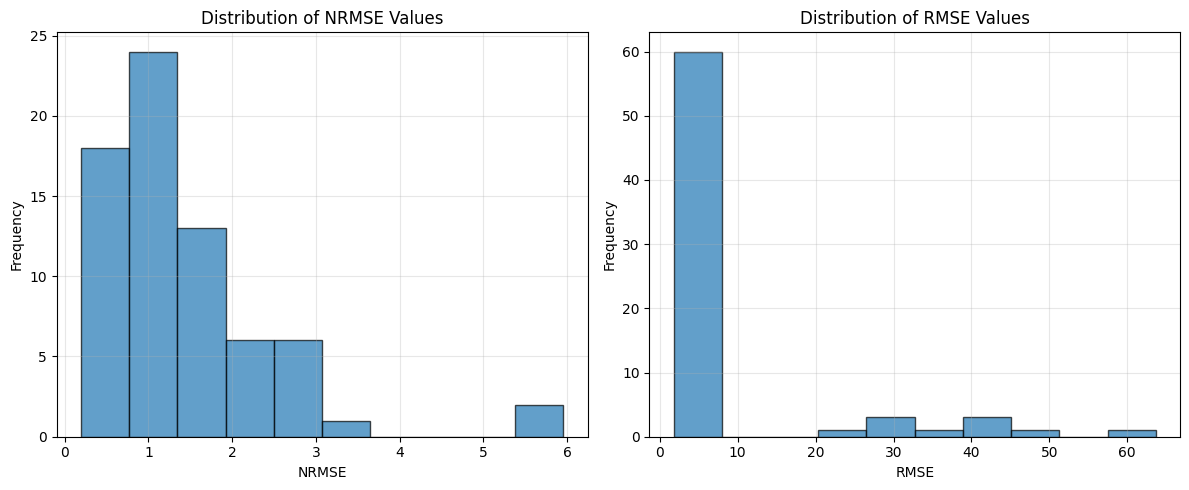


Detailed Results:
Sample ID    Patient    FOV   NRMSE    RMSE    
--------------------------------------------------
004-02       004        02    0.2131   1.9975  
005-01       005        01    0.6575   4.6295  
007-01       007        01    0.4811   6.1631  
008-01       008        01    2.8294   3.0930  
008-02       008        02    0.5649   2.7658  
010-03       010        03    0.9836   2.1421  
012-01       012        01    5.9538   3.4052  
012-02       012        02    2.1473   3.1655  
013-01       013        01    1.7673   3.8623  
014-01       014        01    1.7539   5.3279  
015-01       015        01    0.9994   2.8859  
016-01       016        01    2.9359   3.6309  
016-02       016        02    1.4561   2.9141  
016-03       016        03    0.7008   2.7976  
016-04       016        04    1.7595   5.4537  
016-05       016        05    2.8074   6.3627  
017-01       017        01    1.5121   3.7741  
018-01       018        01    1.3320   4.5521  
018-02       018  

In [8]:

print(f"Performing batch analysis on {len(dataset)} samples...")

# Collect metrics across all samples
sample_metrics = []

# Limit to first 5 samples for demonstration (remove this limit for full analysis)
max_samples = len(dataset)

for i in range(max_samples):
    try:
        sample = dataset[i]
        reduced_conc = sample['reduced_wl']['coef_list']
        gt_conc = sample['gt']['coef_list']
        
        # Calculate error metrics
        sample_nrmse = nrmse(gt_conc, reduced_conc)
        sample_rmse = rmse(gt_conc, reduced_conc)
        
        # Calculate mean concentrations
        mean_reduced = np.mean(reduced_conc, axis=(0, 1))
        mean_gt = np.mean(gt_conc, axis=(0, 1))
        
        sample_metrics.append({
            'id': sample['id'],
            'patient_id': sample['patient_id'],
            'fov': sample['fov'],
            'nrmse': sample_nrmse,
            'rmse': sample_rmse,
            'mean_reduced': mean_reduced,
            'mean_gt': mean_gt
        })
        
    except Exception as e:
        print(f"Error processing sample {i}: {e}")
        continue

if sample_metrics:
    # Calculate summary statistics
    nrmse_values = [m['nrmse'] for m in sample_metrics]
    rmse_values = [m['rmse'] for m in sample_metrics]
    
    print(f"\nSummary Statistics (n={len(sample_metrics)}):")
    print(f"NRMSE - Mean: {np.mean(nrmse_values):.4f}, Std: {np.std(nrmse_values):.4f}")
    print(f"RMSE  - Mean: {np.mean(rmse_values):.4f}, Std: {np.std(rmse_values):.4f}")
    
    # Plot error distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.hist(nrmse_values, bins=10, alpha=0.7, edgecolor='black')
    ax1.set_xlabel('NRMSE')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of NRMSE Values')
    ax1.grid(True, alpha=0.3)
    
    ax2.hist(rmse_values, bins=10, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('RMSE')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of RMSE Values')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create a detailed comparison table
    print(f"\nDetailed Results:")
    print(f"{'Sample ID':<12} {'Patient':<10} {'FOV':<5} {'NRMSE':<8} {'RMSE':<8}")
    print("-" * 50)
    for m in sample_metrics:
        print(f"{m['id']:<12} {m['patient_id']:<10} {m['fov']:<5} {m['nrmse']:<8.4f} {m['rmse']:<8.4f}")

else:
    print("No valid samples processed for batch analysis.")

## Calculate mean and std per channel

In [ ]:
import os
from pathlib import Path

from tqdm import tqdm
from src.constants import HELICOID_VAL_SET, HELICOID_TEST_SET

trainset, _, _ = split_dataset_with_ids(
    dataset, val_ids=HELICOID_VAL_SET, test_ids=HELICOID_TEST_SET
)

# Define output directories for saving statistics
# Create the main statistics directory with subdirectories for gt and reduced_wl
stats_base_dir = "../results/statistics/helicoid"
gt_stats_dir = os.path.join(stats_base_dir, "gt")
reduced_wl_stats_dir = os.path.join(stats_base_dir, "reduced_wl")

# Create directories if they don't exist
Path(gt_stats_dir).mkdir(parents=True, exist_ok=True)
Path(reduced_wl_stats_dir).mkdir(parents=True, exist_ok=True)

print(f"Calculating channel-wise statistics for {len(trainset)} samples...")

# Initialize lists to collect all concentration values per channel
reduced_wl_channels = []
gt_channels = []

# Get the number of channels from the first sample
sample = trainset[0]
n_channels = sample["reduced_wl"]["coef_list"].shape[2]
print(f"Number of channels (molecules): {n_channels}")

# Initialize lists for each channel
for i in range(n_channels):
    reduced_wl_channels.append([])
    gt_channels.append([])

# Collect all concentration values across all samples
for i, sample in enumerate(tqdm(trainset)):
    try:
        reduced_conc = sample["reduced_wl"]["coef_list"]
        gt_conc = sample["gt"]["coef_list"]

        # For each channel, flatten the spatial dimensions and collect values
        for channel_idx in range(n_channels):
            # Flatten spatial dimensions (H, W) to get all pixel values for this channel
            reduced_channel_values = reduced_conc[:, :, channel_idx].flatten()
            gt_channel_values = gt_conc[:, :, channel_idx].flatten()

            reduced_wl_channels[channel_idx].extend(reduced_channel_values)
            gt_channels[channel_idx].extend(gt_channel_values)

    except Exception as e:
        print(f"Error processing sample {i}: {e}")
        continue

print("Calculating statistics and saving to files...")

# Calculate mean and std for each channel and save to files
molecule_names = [
    "HbO2",
    "Hb",
    "oxCCO",
    "redCCO",
    "Cyt-c_oxy",
    "Cyt-c_red",
    "Cyt-b_oxy",
    "Cyt-b_red",
    "Water",
    "Fat",
]

for channel_idx in range(n_channels):
    # Convert to numpy arrays for efficient computation
    reduced_values = np.array(reduced_wl_channels[channel_idx])
    gt_values = np.array(gt_channels[channel_idx])

    # Calculate statistics
    reduced_mean = np.mean(reduced_values)
    reduced_std = np.std(reduced_values)
    gt_mean = np.mean(gt_values)
    gt_std = np.std(gt_values)

    # Save reduced wavelength statistics
    np.save(os.path.join(reduced_wl_stats_dir, f"mean_{channel_idx}.npy"), reduced_mean)
    np.save(os.path.join(reduced_wl_stats_dir, f"std_{channel_idx}.npy"), reduced_std)

    # Save ground truth statistics
    np.save(os.path.join(gt_stats_dir, f"mean_{channel_idx}.npy"), gt_mean)
    np.save(os.path.join(gt_stats_dir, f"std_{channel_idx}.npy"), gt_std)

    # Print summary
    molecule_name = (
        molecule_names[channel_idx]
        if channel_idx < len(molecule_names)
        else f"Channel_{channel_idx}"
    )
    print(f"Channel {channel_idx} ({molecule_name}):")
    print(f"  Reduced WL - Mean: {reduced_mean:.6f}, Std: {reduced_std:.6f}")
    print(f"  Ground Truth - Mean: {gt_mean:.6f}, Std: {gt_std:.6f}")
    print(f"  Sample count: {len(reduced_values):,} pixels")

print(f"\nStatistics saved to:")
print(f"  Base directory: {stats_base_dir}")
print(f"  Reduced WL: {reduced_wl_stats_dir}")
print(f"  Ground Truth: {gt_stats_dir}")

# Verify files were created
print(f"\nFiles created in {reduced_wl_stats_dir}:")
for file in sorted(os.listdir(reduced_wl_stats_dir)):
    print(f"  {file}")

print(f"\nFiles created in {gt_stats_dir}:")
for file in sorted(os.listdir(gt_stats_dir)):
    print(f"  {file}")

print(f"\nNormalization directory structure:")
print(f"{stats_base_dir}/")
print(f"├── gt/")
print(f"│   ├── mean_0.npy, std_0.npy")
print(f"│   ├── mean_1.npy, std_1.npy")
print(f"│   └── ...")
print(f"└── reduced_wl/")
print(f"    ├── mean_0.npy, std_0.npy")
print(f"    ├── mean_1.npy, std_1.npy")
print(f"    └── ...")

Dataset split summary (custom sample IDs):
  Total samples: 70
  Validation IDs: ['013-01', '014-01', '022-02', '027-02']
  Test IDs: ['008-01', '008-02', '012-01', '012-02', '015-01', '016-01', '016-02', '016-03', '016-04', '016-05', '020-01', '025-02']
  Train: 31 patients, 54 samples (77.1%)
  Val: 4 patients, 4 samples (5.7%)
  Test: 6 patients, 12 samples (17.1%)
Calculating channel-wise statistics for 54 samples...
Number of channels (molecules): 10


100%|██████████| 54/54 [00:04<00:00, 11.25it/s]


Calculating statistics and saving to files...
Channel 0 (HbO2):
  Reduced WL - Mean: 0.001343, Std: 0.004344
  Ground Truth - Mean: 0.001112, Std: 0.004007
  Sample count: 3,096,576 pixels
Channel 1 (Hb):
  Reduced WL - Mean: -0.004438, Std: 0.030845
  Ground Truth - Mean: -0.000953, Std: 0.010552
  Sample count: 3,096,576 pixels
Channel 2 (oxCCO):
  Reduced WL - Mean: 0.009409, Std: 0.077869
  Ground Truth - Mean: -0.003880, Std: 0.038258
  Sample count: 3,096,576 pixels
Channel 1 (Hb):
  Reduced WL - Mean: -0.004438, Std: 0.030845
  Ground Truth - Mean: -0.000953, Std: 0.010552
  Sample count: 3,096,576 pixels
Channel 2 (oxCCO):
  Reduced WL - Mean: 0.009409, Std: 0.077869
  Ground Truth - Mean: -0.003880, Std: 0.038258
  Sample count: 3,096,576 pixels
Channel 3 (redCCO):
  Reduced WL - Mean: -0.003150, Std: 0.023688
  Ground Truth - Mean: 0.000575, Std: 0.009577
  Sample count: 3,096,576 pixels
Channel 4 (Cyt-c_oxy):
  Reduced WL - Mean: -0.046626, Std: 0.317761
  Ground Truth - Mea

## Demonstration of Normalization Feature

Now let's demonstrate how to use the normalization feature by creating a new dataset instance with the computed statistics.

In [5]:
# Create a new dataset instance with normalization enabled
# Use the base statistics directory (which contains gt/ and reduced_wl/ subdirectories)
normalized_dataset = ConcentrationsDataset(
    reduced_wl_dir=reduced_wl_dir,
    gt_dir=gt_dir,
    sample_type=SampleType.HELICOID,
    center_crop_size=(256, 224),
    normalization_dir="../results/statistics/helicoid")

print(f"Created normalized dataset with {len(normalized_dataset)} samples")

# Get normalization information
norm_info = normalized_dataset.get_normalization_info()
print(f"\nNormalization enabled: {norm_info['enabled']}")
print(f"Normalization directory: {norm_info['normalization_dir']}")
print(f"Number of GT channels: {norm_info['num_channels_gt']}")
print(f"Number of reduced WL channels: {norm_info['num_channels_reduced_wl']}")

# Display first few normalization statistics for GT
print(f"\nFirst 5 GT channel normalization statistics:")
print(f"{'Channel':<8} {'Mean':<12} {'Std':<12} {'Molecule':<15}")
print("-" * 50)
for i in range(min(5, norm_info['num_channels_gt'])):
    mol_name = molecule_names[i] if i < len(molecule_names) else f"Channel_{i}"
    print(f"{i:<8} {norm_info['gt_means'][i]:<12.6f} {norm_info['gt_stds'][i]:<12.6f} {mol_name:<15}")

# Display first few normalization statistics for Reduced WL
print(f"\nFirst 5 Reduced WL channel normalization statistics:")
print(f"{'Channel':<8} {'Mean':<12} {'Std':<12} {'Molecule':<15}")
print("-" * 50)
for i in range(min(5, norm_info['num_channels_reduced_wl'])):
    mol_name = molecule_names[i] if i < len(molecule_names) else f"Channel_{i}"
    print(f"{i:<8} {norm_info['reduced_wl_means'][i]:<12.6f} {norm_info['reduced_wl_stds'][i]:<12.6f} {mol_name:<15}")

# Compare normalized vs non-normalized data
sample_normalized = normalized_dataset[0]
sample_original = dataset[0]

print(f"\nComparison for sample {sample_normalized['id']}:")
print(f"Original GT data range: [{sample_original['gt']['coef_list'].min():.6f}, {sample_original['gt']['coef_list'].max():.6f}]")
print(f"Normalized GT data range: [{sample_normalized['gt']['coef_list'].min():.6f}, {sample_normalized['gt']['coef_list'].max():.6f}]")
print(f"Original reduced data range: [{sample_original['reduced_wl']['coef_list'].min():.6f}, {sample_original['reduced_wl']['coef_list'].max():.6f}]")
print(f"Normalized reduced data range: [{sample_normalized['reduced_wl']['coef_list'].min():.6f}, {sample_normalized['reduced_wl']['coef_list'].max():.6f}]")

2025-07-07 12:07:29.036 | DEBUG    | src.dataset.concentrations_dataset:_load_stats_from_dir:503 - ground truth - Loaded channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
2025-07-07 12:07:29.037 | DEBUG    | src.dataset.concentrations_dataset:_load_stats_from_dir:504 - ground truth - Means range: [-4.622947, 0.043009]
2025-07-07 12:07:29.038 | DEBUG    | src.dataset.concentrations_dataset:_load_stats_from_dir:507 - ground truth - Stds range: [0.004007, 58.396553]
2025-07-07 12:07:29.042 | DEBUG    | src.dataset.concentrations_dataset:_load_stats_from_dir:503 - reduced wavelength - Loaded channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
2025-07-07 12:07:29.043 | DEBUG    | src.dataset.concentrations_dataset:_load_stats_from_dir:504 - reduced wavelength - Means range: [-14.812694, 0.140868]
2025-07-07 12:07:29.044 | DEBUG    | src.dataset.concentrations_dataset:_load_stats_from_dir:507 - reduced wavelength - Stds range: [0.004344, 60.373951]
2025-07-07 12:07:29.044 | INFO     | src.dataset.concentrations

Found 70 common samples between directories
Created normalized dataset with 70 samples

Normalization enabled: True
Normalization directory: ../results/statistics/helicoid
Number of GT channels: 10
Number of reduced WL channels: 10

First 5 GT channel normalization statistics:
Channel  Mean         Std          Molecule       
--------------------------------------------------
0        0.001112     0.004007     HbO2           
1        -0.000953    0.010552     Hb             
2        -0.003880    0.038258     oxCCO          
3        0.000575     0.009577     redCCO         
4        -0.005537    0.085230     Cyt-c_oxy      

First 5 Reduced WL channel normalization statistics:
Channel  Mean         Std          Molecule       
--------------------------------------------------
0        0.001343     0.004344     HbO2           
1        -0.004438    0.030845     Hb             
2        0.009409     0.077869     oxCCO          
3        -0.003150    0.023688     redCCO         
4    

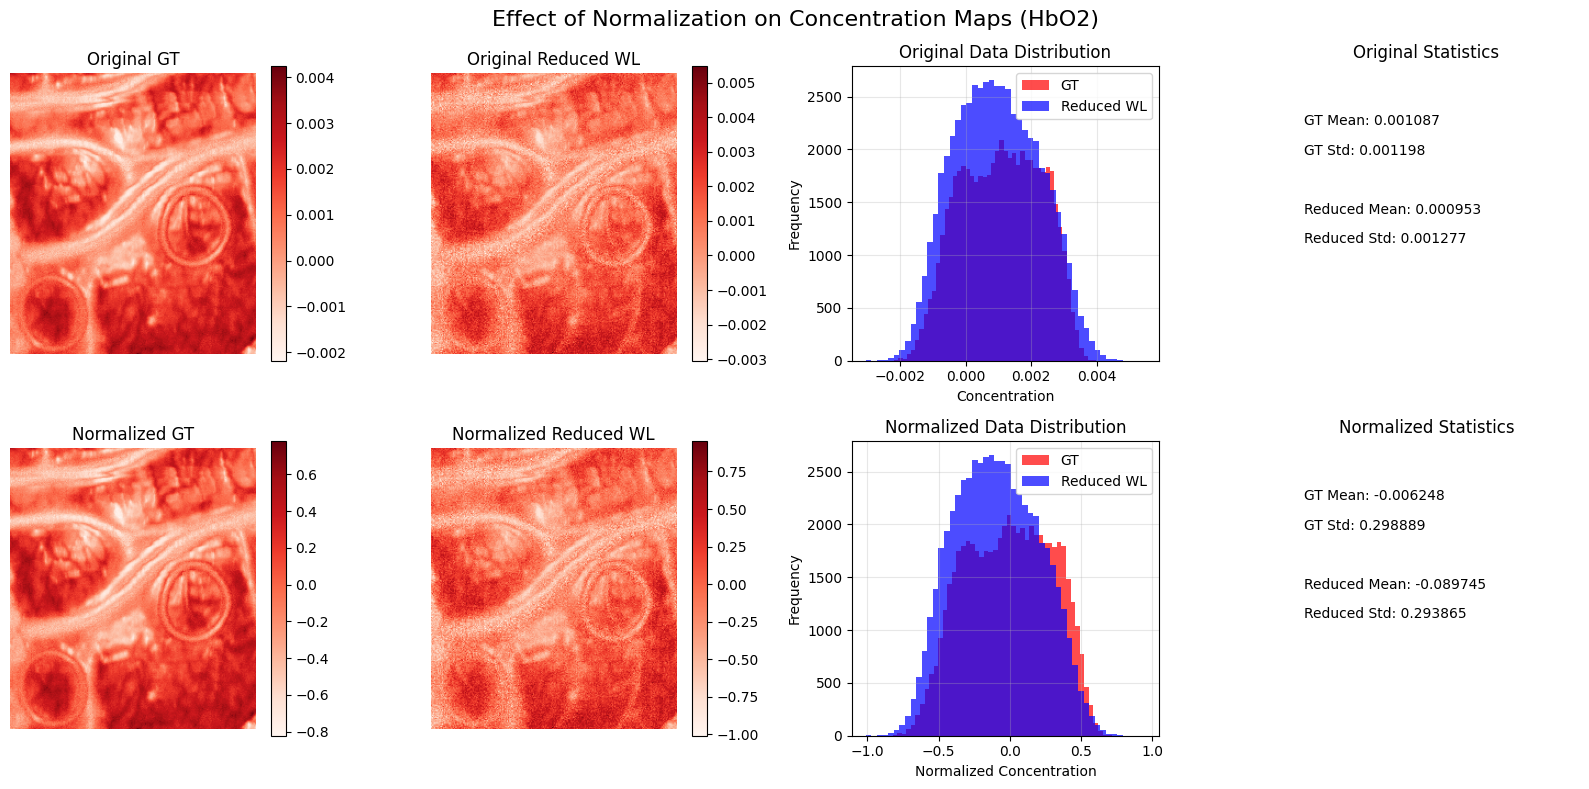


Denormalization verification:
Original GT range: [-69.563210, 34.447308]
Denormalized GT range: [-69.563210, 34.447308]
Max absolute difference GT: 0.0000076294

Original Reduced range: [-82.210846, 25.526524]
Denormalized Reduced range: [-82.210846, 25.526524]
Max absolute difference Reduced: 0.0000076294

Comparison of normalization statistics (first 5 channels):
Channel  GT Mean      RWL Mean     GT Std       RWL Std     
-----------------------------------------------------------------
0        0.001112     0.001343     0.004007     0.004344    
1        -0.000953    -0.004438    0.010552     0.030845    
2        -0.003880    0.009409     0.038258     0.077869    
3        0.000575     -0.003150    0.009577     0.023688    
4        -0.005537    -0.046626    0.085230     0.317761    

This demonstrates that GT and Reduced WL data have different normalization statistics,
which is important for proper training when both are used as inputs/targets.


In [7]:
# Visualize the effect of normalization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Effect of Normalization on Concentration Maps (HbO2)', fontsize=16)

# Get data for visualization
coarseness = 1
molecule_idx = 0  # HbO2

# Original data
orig_gt = sample_original['gt']['coef_list'][::coarseness, ::coarseness, molecule_idx]
orig_reduced = sample_original['reduced_wl']['coef_list'][::coarseness, ::coarseness, molecule_idx]

# Normalized data
norm_gt = sample_normalized['gt']['coef_list'][::coarseness, ::coarseness, molecule_idx]
norm_reduced = sample_normalized['reduced_wl']['coef_list'][::coarseness, ::coarseness, molecule_idx]

# Plot original data
im1 = axes[0, 0].imshow(orig_gt, cmap='Reds')
axes[0, 0].set_title('Original GT')
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0])

im2 = axes[0, 1].imshow(orig_reduced, cmap='Reds')
axes[0, 1].set_title('Original Reduced WL')
axes[0, 1].axis('off')
plt.colorbar(im2, ax=axes[0, 1])

# Plot histograms of original data
axes[0, 2].hist(orig_gt.flatten(), bins=50, alpha=0.7, label='GT', color='red')
axes[0, 2].hist(orig_reduced.flatten(), bins=50, alpha=0.7, label='Reduced WL', color='blue')
axes[0, 2].set_title('Original Data Distribution')
axes[0, 2].set_xlabel('Concentration')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Statistics for original data
axes[0, 3].text(0.1, 0.8, f'GT Mean: {orig_gt.mean():.6f}', transform=axes[0, 3].transAxes)
axes[0, 3].text(0.1, 0.7, f'GT Std: {orig_gt.std():.6f}', transform=axes[0, 3].transAxes)
axes[0, 3].text(0.1, 0.5, f'Reduced Mean: {orig_reduced.mean():.6f}', transform=axes[0, 3].transAxes)
axes[0, 3].text(0.1, 0.4, f'Reduced Std: {orig_reduced.std():.6f}', transform=axes[0, 3].transAxes)
axes[0, 3].set_title('Original Statistics')
axes[0, 3].axis('off')

# Plot normalized data
im3 = axes[1, 0].imshow(norm_gt, cmap='Reds')
axes[1, 0].set_title('Normalized GT')
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0])

im4 = axes[1, 1].imshow(norm_reduced, cmap='Reds')
axes[1, 1].set_title('Normalized Reduced WL')
axes[1, 1].axis('off')
plt.colorbar(im4, ax=axes[1, 1])

# Plot histograms of normalized data
axes[1, 2].hist(norm_gt.flatten(), bins=50, alpha=0.7, label='GT', color='red')
axes[1, 2].hist(norm_reduced.flatten(), bins=50, alpha=0.7, label='Reduced WL', color='blue')
axes[1, 2].set_title('Normalized Data Distribution')
axes[1, 2].set_xlabel('Normalized Concentration')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

# Statistics for normalized data
axes[1, 3].text(0.1, 0.8, f'GT Mean: {norm_gt.mean():.6f}', transform=axes[1, 3].transAxes)
axes[1, 3].text(0.1, 0.7, f'GT Std: {norm_gt.std():.6f}', transform=axes[1, 3].transAxes)
axes[1, 3].text(0.1, 0.5, f'Reduced Mean: {norm_reduced.mean():.6f}', transform=axes[1, 3].transAxes)
axes[1, 3].text(0.1, 0.4, f'Reduced Std: {norm_reduced.std():.6f}', transform=axes[1, 3].transAxes)
axes[1, 3].set_title('Normalized Statistics')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

# Demonstrate denormalization with separate data types
denormalized_gt = normalized_dataset.denormalize(sample_normalized['gt']['coef_list'], 'gt')
denormalized_reduced = normalized_dataset.denormalize(sample_normalized['reduced_wl']['coef_list'], 'reduced_wl')

print(f"\nDenormalization verification:")
print(f"Original GT range: [{sample_original['gt']['coef_list'].min():.6f}, {sample_original['gt']['coef_list'].max():.6f}]")
print(f"Denormalized GT range: [{denormalized_gt.min():.6f}, {denormalized_gt.max():.6f}]")
print(f"Max absolute difference GT: {np.abs(sample_original['gt']['coef_list'] - denormalized_gt).max():.10f}")

print(f"\nOriginal Reduced range: [{sample_original['reduced_wl']['coef_list'].min():.6f}, {sample_original['reduced_wl']['coef_list'].max():.6f}]")
print(f"Denormalized Reduced range: [{denormalized_reduced.min():.6f}, {denormalized_reduced.max():.6f}]")
print(f"Max absolute difference Reduced: {np.abs(sample_original['reduced_wl']['coef_list'] - denormalized_reduced).max():.10f}")

# Show the difference in normalization statistics between GT and Reduced WL
print(f"\nComparison of normalization statistics (first 5 channels):")
print(f"{'Channel':<8} {'GT Mean':<12} {'RWL Mean':<12} {'GT Std':<12} {'RWL Std':<12}")
print("-" * 65)
for i in range(min(5, norm_info['num_channels_gt'])):
    print(f"{i:<8} {norm_info['gt_means'][i]:<12.6f} {norm_info['reduced_wl_means'][i]:<12.6f} "
          f"{norm_info['gt_stds'][i]:<12.6f} {norm_info['reduced_wl_stds'][i]:<12.6f}")

print(f"\nThis demonstrates that GT and Reduced WL data have different normalization statistics,")
print(f"which is important for proper training when both are used as inputs/targets.")

## Plot Error versus number of Wavelenghts


Mean MAE across all datasets: 1.8234


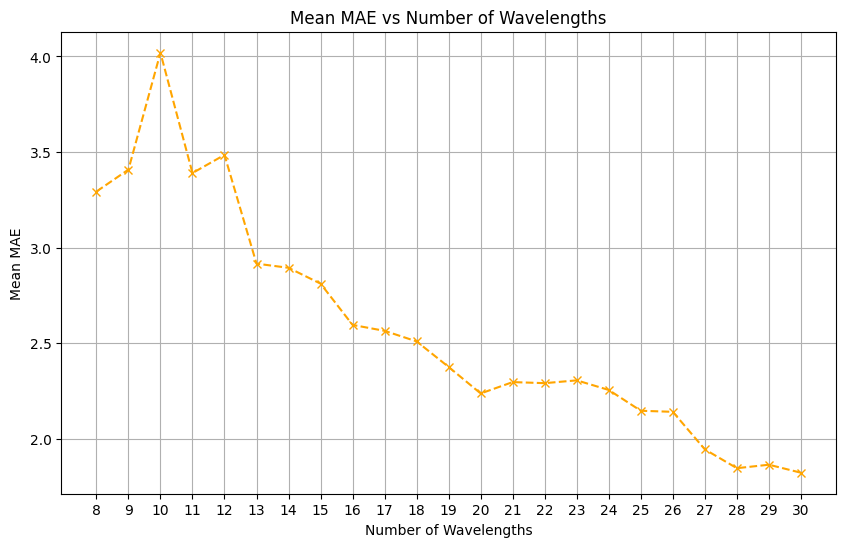

In [ ]:
import matplotlib.pyplot as plt


def calculate_error(dataset):
    total_mae = 0
    mean_mae = 0
    for sample in dataset:
        reduced_conc = sample['reduced_wl']['coef_list']
        gt_conc = sample['gt']['coef_list']

        mae = np.mean(np.abs(gt_conc - reduced_conc))
        mean_mae += mae
        total_mae += mae
    mean_mae /= len(dataset)
    return total_mae, mean_mae

mae_datasets = []
mean_mae_datasets = []
for i in range(8, 31):
    if i == 15:
        reduced_wl_dir = "../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750_reduced"
    else:
        reduced_wl_dir = f"../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750_reduced_wl_set_{i}"
    dataset = ConcentrationsDataset(
        reduced_wl_dir=reduced_wl_dir,
        gt_dir="../results/helicoid_spectral_unmixing/coarseness_1_left_530_right_750",
        sample_type=SampleType.HELICOID,
        center_crop_size=(224, 224),
    )
    total_mae, mean_mae = calculate_error(dataset)
    mae_datasets.append((i, total_mae))
    mean_mae_datasets.append((i, mean_mae))
    print(f"Total MAE for dataset {i}: {total_mae:.4f}")


print(f"\nMean MAE across all datasets: {mean_mae:.4f}")
xs = [p[0] for p in mae_datasets]
ys = [p[1] for p in mae_datasets]

mean_xs = [p[0] for p in mean_mae_datasets]
mean_ys = [p[1] for p in mean_mae_datasets]


fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(xs, ys, marker='o', linestyle='-', color='blue', label='Total MAE')
ax.plot(mean_xs, mean_ys, marker='x', linestyle='--', color='orange', label='Mean MAE')
ax.set_title('Mean MAE vs Number of Wavelengths')
ax.set_xlabel('Number of Wavelengths')
ax.set_ylabel('Mean MAE')
ax.grid(True)

# Force one tick for each x value
ax.set_xticks(sorted(set(xs)))   # or just `ax.set_xticks(xs)` if they’re unique
# Optional: if many ticks, rotate for readability
# ax.tick_params(axis='x', labelrotation=45)

plt.show()